# 第四章 智能体经典范式构建
从零实现三个最具代表性的架构范式
ReAct思考和行动紧密结合即边想边做
Plan-and-Solve先计划再解决三思而后行
Reflection后省后思后行赋予智能体反思能力
## 4.1 环境准备与基础工具定义
### 4.1.1 安装依赖库
pip install openai python-dotenv
### 4.1.2 配置API密钥
LLM_API_KEY="  "
LLM_MODEL_ID="  "
LLM_BASE_URL="  "
### 4.1.3 封装基础 LLM 调用函数
为了让代码结构更清晰、更易于复用，我们来定义一个专属的LLM客户端类。这个类将封装所有与模型服务交互的细节，让我们的主逻辑可以更专注于智能体的构建。

In [2]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from typing import List, Dict

# 加载 .env 文件中的环境变量
load_dotenv()

class HelloAgentsLLM:
    """
    为本书 "Hello Agents" 定制的LLM客户端。
    它用于调用任何兼容OpenAI接口的服务，并默认使用流式响应。
    """
    def __init__(self, model: str = None, apiKey: str = None, baseUrl: str = None, timeout: int = None):
        """
        初始化客户端。优先使用传入参数，如果未提供，则从环境变量加载。
        """
        self.model = model or os.getenv("LLM_MODEL_ID")
        apiKey = apiKey or os.getenv("LLM_API_KEY")
        baseUrl = baseUrl or os.getenv("LLM_BASE_URL")
        timeout = timeout or int(os.getenv("LLM_TIMEOUT", 60))
        
        if not all([self.model, apiKey, baseUrl]):
            raise ValueError("模型ID、API密钥和服务地址必须被提供或在.env文件中定义。")

        self.client = OpenAI(api_key=apiKey, base_url=baseUrl, timeout=timeout)

    def think(self, messages: List[Dict[str, str]], temperature: float = 0) -> str:
        """
        调用大语言模型进行思考，并返回其响应。
        """
        print(f"🧠 正在调用 {self.model} 模型...")
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=messages,
                temperature=temperature,
                stream=True,
            )
            
            # 处理流式响应
            print("✅ 大语言模型响应成功:")
            collected_content = []
            for chunk in response:
                if not chunk.choices:
                    continue
                content = chunk.choices[0].delta.content or ""
                print(content, end="", flush=True)
                collected_content.append(content)
            print()  # 在流式输出结束后换行
            return "".join(collected_content)

        except Exception as e:
            print(f"❌ 调用LLM API时发生错误: {e}")
            return None

# --- 客户端使用示例 ---
if __name__ == '__main__':
    try:
        llmClient = HelloAgentsLLM()
        
        exampleMessages = [
            {"role": "system", "content": "You are a helpful assistant that writes Python code."},
            {"role": "user", "content": "写一个快速排序算法"}
        ]
        
        print("--- 调用LLM ---")
        responseText = llmClient.think(exampleMessages)
        if responseText:
            print("\n\n--- 完整模型响应 ---")
            print(responseText)

    except ValueError as e:
        print(e)


# >>>
# --- 调用LLM ---
# 🧠 正在调用 xxxxxx 模型...
# ✅ 大语言模型响应成功:
# 快速排序是一种非常高效的排序算法...

--- 调用LLM ---
🧠 正在调用 Qwen/Qwen3.5-35B-A3B 模型...
✅ 大语言模型响应成功:
以下是使用 Python 编写的快速排序算法，包含多种实现方式及测试示例，适合学习和实际应用。

---

## 一、基础递归版（原地排序）

```python
def quick_sort(arr):
    """
    快速排序 - 基础递归实现（原地排序）
    """
    if len(arr) <= 1:
        return arr
    
    pivot = arr[len(arr) // 2]  # 选择中间元素作为基准
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    
    return quick_sort(left) + middle + quick_sort(right)
```

---

## 二、原地分区版（空间效率更高）

```python
def quick_sort_inplace(arr, low=0, high=None):
    """
    快速排序 - 原地分区实现（节省空间）
    """
    if high is None:
        high = len(arr) - 1
    
    if low < high:
        pivot_index = partition(arr, low, high)
        quick_sort_inplace(arr, low, pivot_index - 1)
        quick_sort_inplace(arr, pivot_index + 1, high)
    
    return arr

def partition(arr, low, high):
    """
    分区函数：将数组分为小于和大于基准的两部分
    """
    pivot = arr[high]
    i = low - 1
    
    for j in range(low

## 4.2 ReAct
### 4.2.1 ReAct的工作流程
Thought思考，Action执行，Observation观察，Repeat重复。
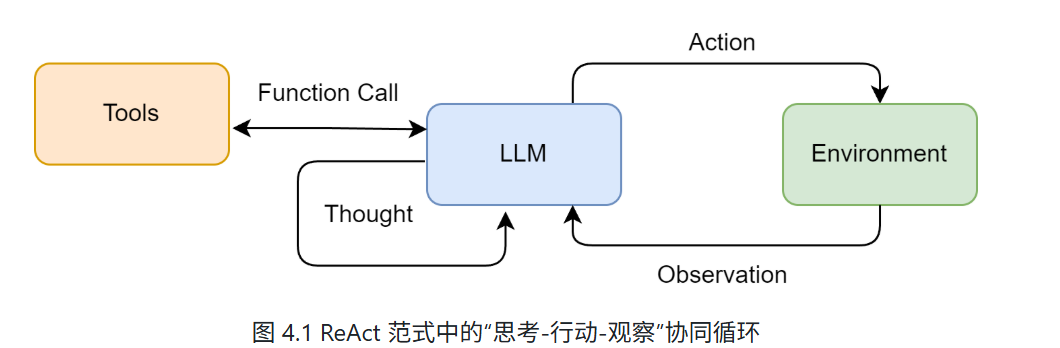

### 4.2.2 工具的定义与实现
首先安装库

pip install google-search-results

同时需要去SerpApi官网注册一个免费账户获取API密钥添加到.env文件中

SERPAPI_API_KEY="  "

实现搜索工具的核心逻辑

一个良好定义的工具应包含以下三个核心要素：

名称 (Name)： 一个简洁、唯一的标识符，供智能体在 Action 中调用，例如 Search。

描述 (Description)： 一段清晰的自然语言描述，说明这个工具的用途。这是整个机制中最关键的部分，因为大语言模型会依赖这段描述来判断何时使用哪个工具。

执行逻辑 (Execution Logic)： 真正执行任务的函数或方法。
我们的第一个工具是 search 函数，它的作用是接收一个查询字符串，然后返回搜索结果。

In [2]:
from serpapi import SerpApiClient

def search(query: str) -> str:
    """
    一个基于SerpApi的实战网页搜索引擎工具。
    它会智能地解析搜索结果，优先返回直接答案或知识图谱信息。
    """
    print(f"🔍 正在执行 [SerpApi] 网页搜索: {query}")
    try:
        api_key = os.getenv("SERPAPI_API_KEY")
        if not api_key:
            return "错误:SERPAPI_API_KEY 未在 .env 文件中配置。"

        params = {
            "engine": "google",
            "q": query,
            "api_key": api_key,
            "gl": "cn",  # 国家代码
            "hl": "zh-cn", # 语言代码
        }
        
        client = SerpApiClient(params)
        results = client.get_dict()
        
        # 智能解析:优先寻找最直接的答案
        if "answer_box_list" in results:
            return "\n".join(results["answer_box_list"])
        if "answer_box" in results and "answer" in results["answer_box"]:
            return results["answer_box"]["answer"]
        if "knowledge_graph" in results and "description" in results["knowledge_graph"]:
            return results["knowledge_graph"]["description"]
        if "organic_results" in results and results["organic_results"]:
            # 如果没有直接答案，则返回前三个有机结果的摘要
            snippets = [
                f"[{i+1}] {res.get('title', '')}\n{res.get('snippet', '')}"
                for i, res in enumerate(results["organic_results"][:3])
            ]
            return "\n\n".join(snippets)
        
        return f"对不起，没有找到关于 '{query}' 的信息。"

    except Exception as e:
        return f"搜索时发生错误: {e}"

上述代码首先检查是否存在answer_box google的答案摘要框或knowledge_graph 知识图谱等信息，如果存在就会返回最精确的答案，不存在才会退而求其次返回前三个常规搜索结果的摘要。这种为LLM提供质量高的信息输入
### （2）构建通用的工具执行器
当智能体需要使用多种工具时（例如，除了搜索，还可能需要计算、查询数据库等），我们需要一个统一的管理器来注册和调度这些工具。为此，我们创建一个 ToolExecutor 类。

In [3]:
from typing import Dict, Any

class ToolExecutor:
    """
    一个工具执行器，负责管理和执行工具。
    """
    def __init__(self):
        self.tools: Dict[str, Dict[str, Any]] = {}

    def registerTool(self, name: str, description: str, func: callable):
        """
        向工具箱中注册一个新工具。
        """
        if name in self.tools:
            print(f"警告:工具 '{name}' 已存在，将被覆盖。")
        self.tools[name] = {"description": description, "func": func}
        print(f"工具 '{name}' 已注册。")

    def getTool(self, name: str) -> callable:
        """
        根据名称获取一个工具的执行函数。
        """
        return self.tools.get(name, {}).get("func")

    def getAvailableTools(self) -> str:
        """
        获取所有可用工具的格式化描述字符串。
        """
        return "\n".join([
            f"- {name}: {info['description']}" 
            for name, info in self.tools.items()
        ])


(3)测试

现在，我们将 search 工具注册到 ToolExecutor 中，并模拟一次调用，以验证整个流程是否正常工作。


In [4]:
# --- 工具初始化与使用示例 ---
if __name__ == '__main__':
    # 1. 初始化工具执行器
    toolExecutor = ToolExecutor()

    # 2. 注册我们的实战搜索工具
    search_description = "一个网页搜索引擎。当你需要回答关于时事、事实以及在你的知识库中找不到的信息时，应使用此工具。"
    toolExecutor.registerTool("Search", search_description, search)
    
    # 3. 打印可用的工具
    print("\n--- 可用的工具 ---")
    print(toolExecutor.getAvailableTools())

    # 4. 智能体的Action调用，这次我们问一个实时性的问题
    print("\n--- 执行 Action: Search['英伟达最新的GPU型号是什么'] ---")
    tool_name = "Search"
    tool_input = "英伟达最新的GPU型号是什么"

    tool_function = toolExecutor.getTool(tool_name)
    if tool_function:
        observation = tool_function(tool_input)
        print("--- 观察 (Observation) ---")
        print(observation)
    else:
        print(f"错误:未找到名为 '{tool_name}' 的工具。")
        
# >>>
# 工具 'Search' 已注册。

# --- 可用的工具 ---
# - Search: 一个网页搜索引擎。当你需要回答关于时事、事实以及在你的知识库中找不到的信息时，应使用此工具。

# --- 执行 Action: Search['英伟达最新的GPU型号是什么'] ---
# 🔍 正在执行 [SerpApi] 网页搜索: 英伟达最新的GPU型号是什么
# --- 观察 (Observation) ---
# [1] GeForce RTX 50 系列显卡
# GeForce RTX™ 50 系列GPU 搭载NVIDIA Blackwell 架构，为游戏玩家和创作者带来全新玩法。RTX 50 系列具备强大的AI 算力，带来升级体验和更逼真的画面。

# [2] 比较GeForce 系列最新一代显卡和前代显卡
# 比较最新一代RTX 30 系列显卡和前代的RTX 20 系列、GTX 10 和900 系列显卡。查看规格、功能、技术支持等内容。

# [3] GeForce 显卡| NVIDIA
# DRIVE AGX. 强大的车载计算能力，适用于AI 驱动的智能汽车系统 · Clara AGX. 适用于创新型医疗设备和成像的AI 计算. 游戏和创作. GeForce. 探索显卡、游戏解决方案、AI ...

工具 'Search' 已注册。

--- 可用的工具 ---
- Search: 一个网页搜索引擎。当你需要回答关于时事、事实以及在你的知识库中找不到的信息时，应使用此工具。

--- 执行 Action: Search['英伟达最新的GPU型号是什么'] ---
🔍 正在执行 [SerpApi] 网页搜索: 英伟达最新的GPU型号是什么
--- 观察 (Observation) ---
[1] 比较GeForce 系列最新一代显卡和前代显卡| NVIDIA
比较最新一代RTX 30 系列显卡和前代的RTX 20 系列、GTX 10 和900 系列显卡。查看规格、功能、技术支持等内容。

[2] 问“英伟达最新的GPU型号是什么”搜不出结果，改成NVIDIA ...
... 型号包括： 1. NVIDIA Tesla V100：这是英伟达推出的最新一代数据中心加速器，采用了Volta架构，拥有5120个CUDA核心和16GB、32GB、甚至是64GB的HBM2显存。

[3] GeForce RTX 50 系列显卡| NVIDIA
GeForce RTX™ 50 系列GPU 搭载NVIDIA Blackwell 架构，为游戏玩家和创作者带来全新玩法。RTX 50 系列具备强大的AI 算力，带来升级体验和更逼真的画面。


这样我们已经为智能体配备了连接真实世界互联网的Search工具，为后续的ReAct循环提供了坚实的基础
## 4.2.3 ReAct 智能体的编码实现
现在，我们将所有独立的组件，LLM客户端和工具执行器组装起来，构建一个完整的 ReAct 智能体。我们将通过一个 ReActAgent 类来封装其核心逻辑。为了便于理解，我们将这个类的实现过程拆分为以下几个关键部分进行讲解。

### （1）系统提示词设计

提示词是整个 ReAct 机制的基石，它为大语言模型提供了行动的操作指令。我们需要精心设计一个模板，它将动态地插入可用工具、用户问题以及中间步骤的交互历史。

In [5]:
# ReAct 提示词模板
REACT_PROMPT_TEMPLATE = """
请注意，你是一个有能力调用外部工具的智能助手。

可用工具如下:
{tools}

请严格按照以下格式进行回应:

Thought: 你的思考过程，用于分析问题、拆解任务和规划下一步行动。
Action: 你决定采取的行动，必须是以下格式之一:
- `{{tool_name}}[{{tool_input}}]`:调用一个可用工具。
- `Finish[最终答案]`:当你认为已经获得最终答案时。
- 当你收集到足够的信息，能够回答用户的最终问题时，你必须在Action:字段后使用 Finish[最终答案] 来输出最终答案。

现在，请开始解决以下问题:
Question: {question}
History: {history}
"""

这个模板定义了智能体和LLM之间交互的规范：

角色定义，工具清单，格式规约，动态上下文
### （2）核心循环的实现

ReActAgent 的核心是一个循环，它不断地“格式化提示词 -> 调用LLM -> 执行动作 -> 整合结果”，直到任务完成或达到最大步数限制。

In [6]:
class ReActAgent:
    def __init__(self, llm_client: HelloAgentsLLM, tool_executor: ToolExecutor, max_steps: int = 5):
        self.llm_client = llm_client
        self.tool_executor = tool_executor
        self.max_steps = max_steps
        self.history = []

    def run(self, question: str):
        """
        运行ReAct智能体来回答一个问题。
        """
        self.history = [] # 每次运行时重置历史记录
        current_step = 0

        while current_step < self.max_steps:
            current_step += 1
            print(f"--- 第 {current_step} 步 ---")

            # 1. 格式化提示词
            tools_desc = self.tool_executor.getAvailableTools()
            history_str = "\n".join(self.history)
            prompt = REACT_PROMPT_TEMPLATE.format(
                tools=tools_desc,
                question=question,
                history=history_str
            )

            # 2. 调用LLM进行思考
            messages = [{"role": "user", "content": prompt}]
            response_text = self.llm_client.think(messages=messages)
            
            if not response_text:
                print("错误:LLM未能返回有效响应。")
                break

            # ... (后续的解析、执行、整合步骤)


run（）方法是智能体的入口。max——steps参数则是一个重要的安全阀，防止智能体陷入死循环而耗尽资源
### （3）输出解析器的实现

LLM 返回的是纯文本，我们需要从中精确地提取出Thought和Action。这是通过几个辅助解析函数完成的，它们通常使用正则表达式来实现。

In [7]:
# (这些方法是 ReActAgent 类的一部分)
def _parse_output(self, text: str):
    """解析LLM的输出，提取Thought和Action。
    """
    # Thought: 匹配到 Action: 或文本末尾
    thought_match = re.search(r"Thought:\s*(.*?)(?=\nAction:|$)", text, re.DOTALL)
    # Action: 匹配到文本末尾
    action_match = re.search(r"Action:\s*(.*?)$", text, re.DOTALL)
    thought = thought_match.group(1).strip() if thought_match else None
    action = action_match.group(1).strip() if action_match else None
    return thought, action

def _parse_action(self, action_text: str):
    """解析Action字符串，提取工具名称和输入。
    """
    match = re.match(r"(\w+)\[(.*)\]", action_text, re.DOTALL)
    if match:
        return match.group(1), match.group(2)
    return None, None

_parse_out:负责从LLM的完整响应中分离出Thought和Action两个主要部分  _parse_action: 负责京一部解析Action字符串，列如从Search[华为最新手机]中提取出工具名Search和工具输入 华为最新手机 
### （4）工具调用与执行


In [ ]:
# (这段逻辑在 run 方法的 while 循环内)
# 3. 解析LLM的输出
thought, action = self._parse_output(response_text)

if thought:
    print(f"思考: {thought}")


if not action:
    print("警告:未能解析出有效的Action，流程终止。")
    break

# 4. 执行Action
if action.startswith("Finish"):
                # 如果是Finish指令，提取最终答案并结束
                # 使用 re.DOTALL 匹配跨行内容
                matchOk = re.match(r"Finish\[(.*)\]", action, re.DOTALL)
                if matchOk:
                    # 如果匹配成功，提取最终答案并结束循环
                    final_answer = matchOk.group(1)
                    print(f"🎉 最终答案: {final_answer}")
                    return final_answer
                else:
                    # 如果LLM没有遵循标准格式输出，做兜底处理
                    print(
                        f"⚠ 警告: 虽然包含Finish，但格式不正确，提取失败。原始输出为：{action}"
                    )
                    # 为了程序不崩溃，可以把action当作答案返回，或者抛出具体错误
                    final_answer = action.replace("Finish[", "").strip(":[]")
                    # 尝试简单粗暴清洗一下
                    print(f"🤔 强制返回清洗后的结果为：{final_answer}")
                    return final_answer

tool_name, tool_input = self._parse_action(action)
if not tool_name or not tool_input:
    # ... 处理无效Action格式 ...
    continue

print(f"🎬 行动: {tool_name}[{tool_input}]")

tool_function = self.tool_executor.getTool(tool_name)
if not tool_function:
    observation = f"错误:未找到名为 '{tool_name}' 的工具。"
else:
    observation = tool_function(tool_input) # 调用真实工具


这段代码是Action的执行中心，先检查是否为Finish指令，是则流程结束，否则通过tool_executor获得对应工具函数并执行得到observation。
### （5）观测结果的整合
最后一步，也是形成闭环的关键，是将Action本身和工具执行后的Observation添加回历史记录中，为下一轮循环提供新的上下文。

In [ ]:
# (这段逻辑紧随工具调用之后，在 while 循环的末尾)
            print(f"👀 观察: {observation}")
            
            # 将本轮的Action和Observation添加到历史记录中
            self.history.append(f"Action: {action}")
            self.history.append(f"Observation: {observation}")

        # 循环结束
        print("已达到最大步数，流程终止。")
        return None

通过Observation追加到self.history中，形成新的上下文，为下一轮循环提供信息。
### （6）运行实例与分析
将以上所有部分组合起来，我们就得到了完整的 ReActAgent 类。完整的代码运行实例可以在本书配套的代码仓库 code 文件夹中找到。

下面是一次真实的运行记录：


工具 'Search' 已注册。

--- 第 1 步 ---
🧠 正在调用 xxxxxx 模型...
✅ 大语言模型响应成功:
Thought: 要回答这个问题，我需要查找华为最新发布的手机型号及其主要特点。这些信息可能在我的现有知识库之外，因此需要使用搜索引擎来获取最新数据。
Action: Search[华为最新手机型号及主要卖点]
🤔 思考: 要回答这个问题，我需要查找华为最新发布的手机型号及其主要特点。这些信息可能在我的现有知识库之外，因此需要使用搜索引擎来获取最新数据。
🎬 行动: Search[华为最新手机型号及主要卖点]
🔍 正在执行 [SerpApi] 网页搜索: 华为最新手机型号及主要卖点
👀 观察: [1] 华为手机- 华为官网
智能手机 ; Mate 系列. 非凡旗舰 · HUAWEI Mate XTs. 非凡大师 ; Pura 系列. 先锋影像 · HUAWEI Pura 80 Pro+ ; Pocket 系列. 美学新篇. HUAWEI Pocket 2 ; nova 系列. 专业人像.

[2] 2025年华为手机哪一款性价比高？华为手机推荐与市场分析 ...
现在华为手机最大的卖点只剩下鸿蒙HarmonyOS系统，以及饱受争议的品牌信仰。 这里推荐目前值得入手的几款华为系列手机，根据不同预算自行选择:. 华为目前最受欢迎，也是搭载 ...

[3] 2025年华为新款手机哪个性价比高？10款华为新款手机推荐
选华为主要还是要推荐高端手机，Mate 70和Pura 70系列是最新发布的旗舰机型。 HUAWEI Mate 70. 优点是，拍照配置依旧顶级，全焦段覆盖，适合专业摄影，做工出色，户外抗摔 ...

--- 第 2 步 ---
🧠 正在调用 xxxxxx 模型...
✅ 大语言模型响应成功:
Thought: 根据搜索结果，华为最新发布的旗舰机型包括Mate 70和Pura 80 Pro+。为了确定最新型号及其主要卖点，我将重点放在这些信息上。从提供的链接来看，Mate 70系列和Pura 80 Pro+都是近期发布的产品，但具体哪一个是“最新”还需要进一步确认。同时，我可以从这些信息中提取出它们的主要
卖点。
Action: Finish[根据最新信息，华为的最新手机可能是HUAWEI Pura 80 Pro+或HUAWEI Mate 70。其中，HUAWEI Mate 70的主要卖点包括顶级的拍照配置，全焦段覆盖，适合专业摄影，做工出色，并且具有良好的户外抗摔性能。而HUAWEI Pura 80 Pro+则强调了先锋影像技术。]
🤔 思考: 根据搜索结果，华为最新发布的旗舰机型包括Mate 70和Pura 80 Pro+。为了确定最新型号及其主要卖点，我将重点放在这些信息上。从提供的链接来看，Mate 70系列和Pura 80 Pro+都是近期发布的产品，但具体哪一个是“最新”还需要进一步确认。同时，我可以从这些信息中提取出它们的主要 
卖点。
🎉 最终答案: 根据最新信息，华为的最新手机可能是HUAWEI Pura 80 Pro+或HUAWEI Mate 70。其中，HUAWEI Mate 70的主要卖点包括顶级的拍照配置，全焦段覆盖，适合专业摄影，做工出色，并且具有良好的户外抗摔性能。而HUAWEI Pura 80 Pro+则强调了先锋影像技术。

## 4.2.4 ReAct 的特点、局限性与调试技巧
通过亲手实现一个 ReAct 智能体，我们不仅掌握了其工作流程，也应该对其内在机制有了更深刻的认识。任何技术范式都有其闪光点和待改进之处，本节将对 ReAct 进行总结。
### 4.3 Plan-and-Solve
在我们掌握了 ReAct 这种反应式的、步进决策的智能体范式后，接下来将探讨一种风格迥异但同样强大的方法，Plan-and-Solve。顾名思义，这种范式将任务处理明确地分为两个阶段：先规划 (Plan)，后执行 (Solve)。

如果说 ReAct 像一个经验丰富的侦探，根据现场的蛛丝马迹（Observation）一步步推理，随时调整自己的调查方向；那么 Plan-and-Solve 则更像一位建筑师，在动工之前必须先绘制出完整的蓝图（Plan），然后严格按照蓝图来施工（Solve）。事实上我们现在用的很多大模型工具的Agent模式都融入了这种设计模式。

#### 4.3.1 Plan-and-Solve 的工作原理
1.规划阶段：将问题分解并制定一个清晰，分步骤的行动计划
2.执行阶段：严格按照计划中的步骤逐一执行最终得到答案
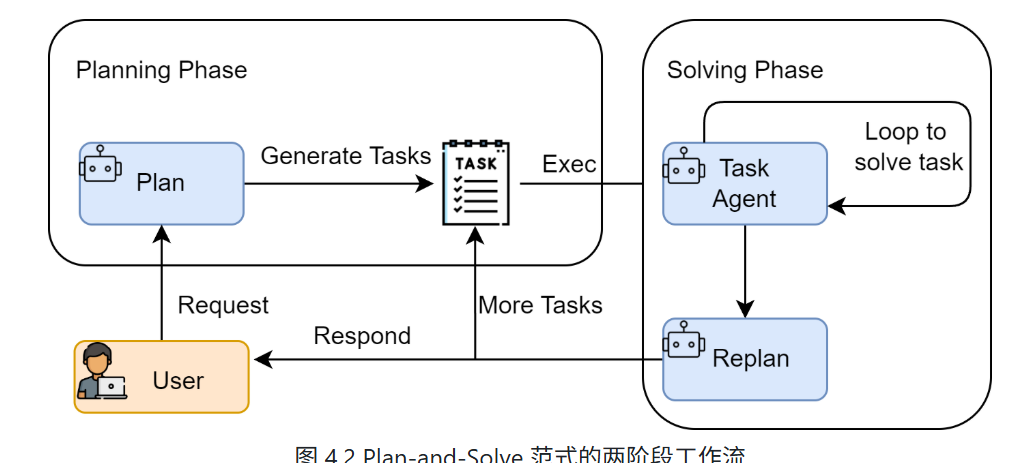

### 4.3.2 规划阶段
规划阶段首先将问题分解为三个独立的计算步骤（计算周二销量，计算周三销量，计算总销量）
执行阶段然后严格按照计划一步一步执行计算并将每一步结果作为下一步计算的输出最终得到答案。
接下来我们设计一个提示词需要明确地告诉模型他的角色和任务，并给出一个输出格式的范例。

In [ ]:
PLANNER_PROMPT_TEMPLATE = """
你是一个顶级的AI规划专家。你的任务是将用户提出的复杂问题分解成一个由多个简单步骤组成的行动计划。
请确保计划中的每个步骤都是一个独立的、可执行的子任务，并且严格按照逻辑顺序排列。
你的输出必须是一个Python列表，其中每个元素都是一个描述子任务的字符串。

问题: {question}

请严格按照以下格式输出你的计划,```python与```作为前后缀是必要的:
```python
["步骤1", "步骤2", "步骤3", ...]
```
"""

这个提示词通过以下几点确保了输出的质量和稳定性：

##### 角色设定： “顶级的AI规划专家”，激发模型的专业能力。
##### 任务描述： 清晰地定义了“分解问题”的目标。
##### 格式约束： 强制要求输出为一个 Python 列表格式的字符串，这极大地简化了后续代码的解析工作，使其比解析自然语言更稳定、更可靠。

接下来，我们将这个提示词逻辑封装成一个 Planner 类，这个类也是我们的规划器。

In [1]:
# 假定 llm_client.py 中的 HelloAgentsLLM 类已经定义好
# from llm_client import HelloAgentsLLM

class Planner:
    def __init__(self, llm_client):
        self.llm_client = llm_client

    def plan(self, question: str) -> list[str]:
        """
        根据用户问题生成一个行动计划。
        """
        prompt = PLANNER_PROMPT_TEMPLATE.format(question=question)
        
        # 为了生成计划，我们构建一个简单的消息列表
        messages = [{"role": "user", "content": prompt}]
        
        print("--- 正在生成计划 ---")
        # 使用流式输出来获取完整的计划
        response_text = self.llm_client.think(messages=messages) or ""
        
        print(f"✅ 计划已生成:\n{response_text}")
        
        # 解析LLM输出的列表字符串
        try:
            # 找到```python和```之间的内容
            plan_str = response_text.split("```python")[1].split("```")[0].strip()
            # 使用ast.literal_eval来安全地执行字符串，将其转换为Python列表
            plan = ast.literal_eval(plan_str)
            return plan if isinstance(plan, list) else []
        except (ValueError, SyntaxError, IndexError) as e:
            print(f"❌ 解析计划时出错: {e}")
            print(f"原始响应: {response_text}")
            return []
        except Exception as e:
            print(f"❌ 解析计划时发生未知错误: {e}")
            return []

### 执行器与状态管理
执行器不仅负责调用大语言模型来解决每个问题还承担状态管理，记录每步结果并将其作为上下文提供后续步骤确保信息在整个任务链条中顺畅流动
提示词需要有：
#### 原始问题，完整计划，历史步骤与结果，当前步骤

In [ ]:
EXECUTOR_PROMPT_TEMPLATE = """
你是一位顶级的AI执行专家。你的任务是严格按照给定的计划，一步步地解决问题。
你将收到原始问题、完整的计划、以及到目前为止已经完成的步骤和结果。
请你专注于解决“当前步骤”，并仅输出该步骤的最终答案，不要输出任何额外的解释或对话。

# 原始问题:
{question}

# 完整计划:
{plan}

# 历史步骤与结果:
{history}

# 当前步骤:
{current_step}

请仅输出针对“当前步骤”的回答:
"""

我们将执行逻辑封装到Executor类中这个类将循环遍历计划调用LLM并维护一个历史记录

In [ ]:
class Executor:
    def __init__(self, llm_client):
        self.llm_client = llm_client

    def execute(self, question: str, plan: list[str]) -> str:
        """
        根据计划，逐步执行并解决问题。
        """
        history = "" # 用于存储历史步骤和结果的字符串
        
        print("\n--- 正在执行计划 ---")
        
        for i, step in enumerate(plan):
            print(f"\n-> 正在执行步骤 {i+1}/{len(plan)}: {step}")
            
            prompt = EXECUTOR_PROMPT_TEMPLATE.format(
                question=question,
                plan=plan,
                history=history if history else "无", # 如果是第一步，则历史为空
                current_step=step
            )
            
            messages = [{"role": "user", "content": prompt}]
            
            response_text = self.llm_client.think(messages=messages) or ""
            
            # 更新历史记录，为下一步做准备
            history += f"步骤 {i+1}: {step}\n结果: {response_text}\n\n"
            
            print(f"✅ 步骤 {i+1} 已完成，结果: {response_text}")

        # 循环结束后，最后一步的响应就是最终答案
        final_answer = response_text
        return final_answer

现在分别构建了负责规划的planner和负责执行的executor，最后一步就是将这两个组件整合到一个完整统一的智能体PlanAndSolveAgent中并赋予它解决问题的完整能力，我们将创建一个主类PlanAndSolveAgent，他的职责非常清晰：接收一个LLM客户端，初始化内部的规划器和执行器并提供一个简单的run（）方法启动整个流程

In [ ]:
class PlanAndSolveAgent:
    def __init__(self, llm_client):
        """
        初始化智能体，同时创建规划器和执行器实例。
        """
        self.llm_client = llm_client
        self.planner = Planner(self.llm_client)
        self.executor = Executor(self.llm_client)

    def run(self, question: str):
        """
        运行智能体的完整流程:先规划，后执行。
        """
        print(f"\n--- 开始处理问题 ---\n问题: {question}")
        
        # 1. 调用规划器生成计划
        plan = self.planner.plan(question)
        
        # 检查计划是否成功生成
        if not plan:
            print("\n--- 任务终止 --- \n无法生成有效的行动计划。")
            return

        # 2. 调用执行器执行计划
        final_answer = self.executor.execute(question, plan)
        
        print(f"\n--- 任务完成 ---\n最终答案: {final_answer}")

这个设计体现了组合优于继承的原则，它不包含复杂逻辑而是作为一个协调者，清晰的调用内部组件完成任务

### 4.3.4 运行实例与分析

In [ ]:
--- 开始处理问题 ---
问题: 一个水果店周一卖出了15个苹果。周二卖出的苹果数量是周一的两倍。周三卖出的数量比周二少了5个。请问这三天总共卖出了多少个苹果？
--- 正在生成计划 ---
🧠 正在调用 xxxx 模型...
✅ 大语言模型响应成功:
```python
["计算周一卖出的苹果数量： 15个", "计算周二卖出的苹果数量： 周一数量 × 2 = 15 × 2 = 30个", "计算周三卖出的苹果数量： 周二数量 - 5 = 30 - 5 = 25个", "计算三天总销量： 周一 + 周二 + 周三 = 15 + 30 + 25 = 70个"]
```
✅ 计划已生成:
```python
["计算周一卖出的苹果数量： 15个", "计算周二卖出的苹果数量： 周一数量 × 2 = 15 × 2 = 30个", "计算周三卖出的苹果数量： 周二数量 - 5 = 30 - 5 = 25个", "计算三天总销量： 周一 + 周二 + 周三 = 15 + 30 + 25 = 70个"]
```

--- 正在执行计划 ---

-> 正在执行步骤 1/4: 计算周一卖出的苹果数量: 15个
🧠 正在调用 xxxx 模型...
✅ 大语言模型响应成功:
15
✅ 步骤 1 已完成，结果: 15

-> 正在执行步骤 2/4: 计算周二卖出的苹果数量: 周一数量 × 2 = 15 × 2 = 30个
🧠 正在调用 xxxx 模型...
✅ 大语言模型响应成功:
30
✅ 步骤 2 已完成，结果: 30

-> 正在执行步骤 3/4: 计算周三卖出的苹果数量: 周二数量 - 5 = 30 - 5 = 25个
🧠 正在调用 xxxx 模型...
✅ 大语言模型响应成功:
25
✅ 步骤 3 已完成，结果: 25

-> 正在执行步骤 4/4: 计算三天总销量: 周一 + 周二 + 周三 = 15 + 30 + 25 = 70个
🧠 正在调用 xxxx 模型...
✅ 大语言模型响应成功:
70
✅ 步骤 4 已完成，结果: 70

--- 任务完成 ---
最终答案: 70

## Reflection
Reflection的核心思想是为智能体引入一种事后的自我校正循环。
### Reflection 机制的核心思想 执行-反思-优化
反思多个维度：事实性错误，逻辑漏洞，效率问题，遗漏信息
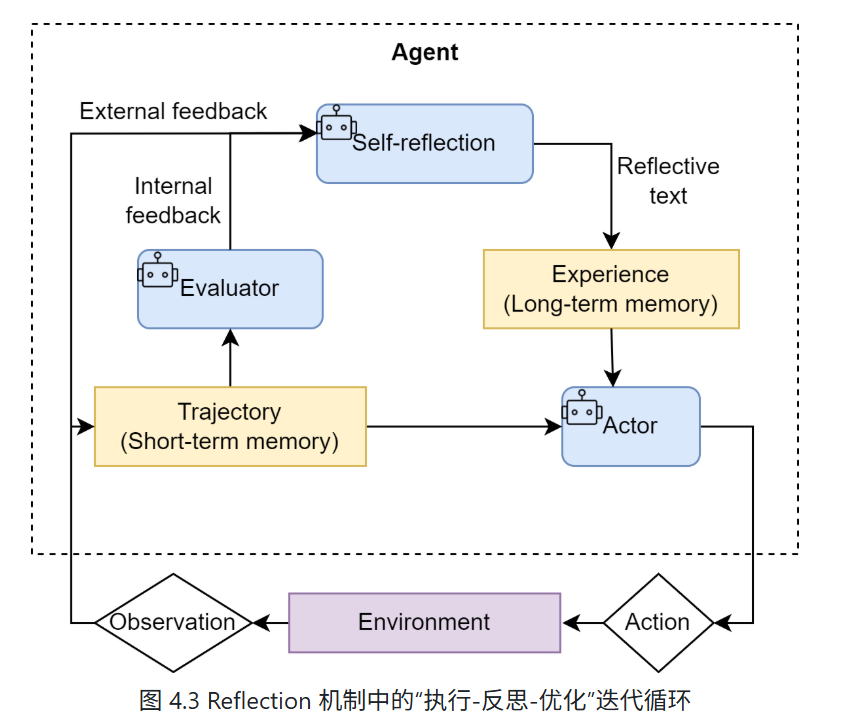

它的价值在于：

提供内部纠错回路不完全依赖外部工具的反馈，能够修正优化更高层次的逻辑和策略问题。。。。。它将一次性任务执行转化为持续优化的过程提升最终成功率和答案质量。。。。。构建临时的短期记忆，进一步它可以是多模态允许智能体反思为更强的智能体打下基础

### 案例设定与记忆模块设计
为了在实战中体现 Reflection 机制，我们将引入记忆管理机制，因为reflection通常对应着信息的存储和提取，如果上下文足够长的情况，想让“评审员”直接获取所有的信息然后进行反思往往会传入很多冗余信息。这一步实践我们主要完成代码生成与迭代优化

检验的绝佳场景：存在明确优化路径，反思点清晰，优化方向明确

这个记忆模块将负责存储每一次“执行-反思”循环的完整轨迹


In [ ]:
from typing import List, Dict, Any, Optional

class Memory:
    """
    一个简单的短期记忆模块，用于存储智能体的行动与反思轨迹。
    """

    def __init__(self):
        """
        初始化一个空列表来存储所有记录。
        """
        self.records: List[Dict[str, Any]] = []

    def add_record(self, record_type: str, content: str):
        """
        向记忆中添加一条新记录。

        参数:
        - record_type (str): 记录的类型 ('execution' 或 'reflection')。
        - content (str): 记录的具体内容 (例如，生成的代码或反思的反馈)。
        """
        record = {"type": record_type, "content": content}
        self.records.append(record)
        print(f"📝 记忆已更新，新增一条 '{record_type}' 记录。")

    def get_trajectory(self) -> str:
        """
        将所有记忆记录格式化为一个连贯的字符串文本，用于构建提示词。
        """
        trajectory_parts = []
        for record in self.records:
            if record['type'] == 'execution':
                trajectory_parts.append(f"--- 上一轮尝试 (代码) ---\n{record['content']}")
            elif record['type'] == 'reflection':
                trajectory_parts.append(f"--- 评审员反馈 ---\n{record['content']}")
        
        return "\n\n".join(trajectory_parts)

    def get_last_execution(self) -> Optional[str]:
        """
        获取最近一次的执行结果 (例如，最新生成的代码)。
        如果不存在，则返回 None。
        """
        for record in reversed(self.records):
            if record['type'] == 'execution':
                return record['content']
        return None

这个 Memory 类的设计比较简洁，主体是这样的：

使用一个列表 records 来按顺序存储每一次的行动和反思。

add_record 方法负责向记忆中添加新的条目。

get_trajectory 方法是核心，它将记忆轨迹“序列化”成一段文本，可以直接插入到后续的提示词中，为模型的反思和优化提供完整的上下文。

get_last_execution 方便我们获取最新的“初稿”以供反思。
### Reflection智能体的编码实现
提示词设计



In [ ]:
INITIAL_PROMPT_TEMPLATE = """
你是一位资深的Python程序员。请根据以下要求，编写一个Python函数。
你的代码必须包含完整的函数签名、文档字符串，并遵循PEP 8编码规范。

要求: {task}

请直接输出代码，不要包含任何额外的解释。
"""

反思提示词

In [ ]:
REFLECT_PROMPT_TEMPLATE = """
你是一位极其严格的代码评审专家和资深算法工程师，对代码的性能有极致的要求。
你的任务是审查以下Python代码，并专注于找出其在<strong>算法效率</strong>上的主要瓶颈。

# 原始任务:
{task}

# 待审查的代码:
```python
{code}
```

请分析该代码的时间复杂度，并思考是否存在一种<strong>算法上更优</strong>的解决方案来显著提升性能。
如果存在，请清晰地指出当前算法的不足，并提出具体的、可行的改进算法建议（例如，使用筛法替代试除法）。
如果代码在算法层面已经达到最优，才能回答“无需改进”。

请直接输出你的反馈，不要包含任何额外的解释。
"""

优化提示词

In [ ]:

REFINE_PROMPT_TEMPLATE = """
你是一位资深的Python程序员。你正在根据一位代码评审专家的反馈来优化你的代码。

# 原始任务:
{task}

# 你上一轮尝试的代码:
{last_code_attempt}
评审员的反馈：
{feedback}

请根据评审员的反馈，生成一个优化后的新版本代码。
你的代码必须包含完整的函数签名、文档字符串，并遵循PEP 8编码规范。
请直接输出优化后的代码，不要包含任何额外的解释。
"""

### 智能体的实现
将提示词逻辑和memory模块整合到ReflectionAgent类中

In [ ]:
# 假设 llm_client.py 和 memory.py 已定义
# from llm_client import HelloAgentsLLM
# from memory import Memory

class ReflectionAgent:
    def __init__(self, llm_client, max_iterations=3):
        self.llm_client = llm_client
        self.memory = Memory()
        self.max_iterations = max_iterations

    def run(self, task: str):
        print(f"\n--- 开始处理任务 ---\n任务: {task}")

        # --- 1. 初始执行 ---
        print("\n--- 正在进行初始尝试 ---")
        initial_prompt = INITIAL_PROMPT_TEMPLATE.format(task=task)
        initial_code = self._get_llm_response(initial_prompt)
        self.memory.add_record("execution", initial_code)

        # --- 2. 迭代循环:反思与优化 ---
        for i in range(self.max_iterations):
            print(f"\n--- 第 {i+1}/{self.max_iterations} 轮迭代 ---")

            # a. 反思
            print("\n-> 正在进行反思...")
            last_code = self.memory.get_last_execution()
            reflect_prompt = REFLECT_PROMPT_TEMPLATE.format(task=task, code=last_code)
            feedback = self._get_llm_response(reflect_prompt)
            self.memory.add_record("reflection", feedback)

            # b. 检查是否需要停止
            if "无需改进" in feedback:
                print("\n✅ 反思认为代码已无需改进，任务完成。")
                break

            # c. 优化
            print("\n-> 正在进行优化...")
            refine_prompt = REFINE_PROMPT_TEMPLATE.format(
                task=task,
                last_code_attempt=last_code,
                feedback=feedback
            )
            refined_code = self._get_llm_response(refine_prompt)
            self.memory.add_record("execution", refined_code)
        
        final_code = self.memory.get_last_execution()
        print(f"\n--- 任务完成 ---\n最终生成的代码:\n```python\n{final_code}\n```")
        return final_code

    def _get_llm_response(self, prompt: str) -> str:
        """一个辅助方法，用于调用LLM并获取完整的流式响应。"""
        messages = [{"role": "user", "content": prompt}]
        response_text = self.llm_client.think(messages=messages) or ""
        return response_text
